In [15]:
import pandas as pd
import numpy as np
from scipy.stats import norm


df = pd.read_excel('Indices_Download_2026.xlsx')
df['Date'] = pd.to_datetime(df['Date'])

#df = df.set_index('Date')

#df = df.loc['2025-01-02':'2026-01-15']


start = '2025-01-02'
end = '2026-01-15'

df_filtered = df[(df['Date'] >= start) & (df['Date'] <= end)]



df_new = df_filtered[['Date','^GSPC']]

print(df_new)

           Date        ^GSPC
2318 2025-01-02  5868.549805
2319 2025-01-03  5942.470215
2320 2025-01-06  5975.379883
2321 2025-01-07  5909.029785
2322 2025-01-08  5918.250000
...         ...          ...
2573 2026-01-09  6966.279785
2574 2026-01-12  6977.270020
2575 2026-01-13  6963.740234
2576 2026-01-14  6926.600098
2577 2026-01-15  6944.470215

[260 rows x 2 columns]


In [16]:
df_new['returns'] = np.log(df['^GSPC'] / df['^GSPC'].shift(1))
df_new = df_new.dropna()

print(df_new)

           Date        ^GSPC   returns
2318 2025-01-02  5868.549805 -0.002226
2319 2025-01-03  5942.470215  0.012517
2320 2025-01-06  5975.379883  0.005523
2321 2025-01-07  5909.029785 -0.011166
2322 2025-01-08  5918.250000  0.001559
...         ...          ...       ...
2573 2026-01-09  6966.279785  0.006455
2574 2026-01-12  6977.270020  0.001576
2575 2026-01-13  6963.740234 -0.001941
2576 2026-01-14  6926.600098 -0.005348
2577 2026-01-15  6944.470215  0.002577

[260 rows x 3 columns]


In [17]:
df_new['vol_21D'] = df_new['returns'].rolling(window=21).std()

df_new = df_new.dropna()

print(df_new.head(25))

           Date        ^GSPC   returns   vol_21D
2338 2025-02-03  5994.569824 -0.007638  0.008841
2339 2025-02-04  6037.879883  0.007199  0.008913
2340 2025-02-05  6061.479980  0.003901  0.008565
2341 2025-02-06  6083.569824  0.003638  0.008524
2342 2025-02-07  6025.990234 -0.009510  0.008414
2343 2025-02-10  6066.439941  0.006690  0.008507
2344 2025-02-11  6068.500000  0.000340  0.007606
2345 2025-02-12  6051.970215 -0.002728  0.007674
2346 2025-02-13  6115.069824  0.010372  0.007899
2347 2025-02-14  6114.629883 -0.000072  0.007007
2348 2025-02-18  6129.580078  0.002442  0.006966
2349 2025-02-19  6144.149902  0.002374  0.006699
2350 2025-02-20  6117.520020 -0.004344  0.006566
2351 2025-02-21  6013.129883 -0.017211  0.007484
2352 2025-02-24  5983.250000 -0.004981  0.007416
2353 2025-02-25  5955.250000 -0.004691  0.007449
2354 2025-02-26  5956.060059  0.000136  0.006774
2355 2025-02-27  5861.569824 -0.015992  0.007199
2356 2025-02-28  5954.500000  0.015730  0.008091
2357 2025-03-03  584

In [6]:
import math as mt
factor = norm.ppf(1-0.99)
print(factor)

-2.3263478740408408


In [18]:
df_new['VaR_t']=df_new['vol_21D']*mt.sqrt(10)*factor

print(df_new)

           Date        ^GSPC   returns   vol_21D     VaR_t
2338 2025-02-03  5994.569824 -0.007638  0.008841 -0.065037
2339 2025-02-04  6037.879883  0.007199  0.008913 -0.065566
2340 2025-02-05  6061.479980  0.003901  0.008565 -0.063006
2341 2025-02-06  6083.569824  0.003638  0.008524 -0.062707
2342 2025-02-07  6025.990234 -0.009510  0.008414 -0.061899
...         ...          ...       ...       ...       ...
2573 2026-01-09  6966.279785  0.006455  0.005953 -0.043792
2574 2026-01-12  6977.270020  0.001576  0.005804 -0.042694
2575 2026-01-13  6963.740234 -0.001941  0.005819 -0.042811
2576 2026-01-14  6926.600098 -0.005348  0.005408 -0.039786
2577 2026-01-15  6944.470215  0.002577  0.005397 -0.039701

[240 rows x 5 columns]


In [20]:
df_new['ret_fwd_10'] = np.log(df_new['^GSPC'].shift(-10) / df_new['^GSPC'])

df_new = df_new.dropna()
print(df_new)

           Date        ^GSPC   returns   vol_21D     VaR_t  ret_fwd_10
2338 2025-02-03  5994.569824 -0.007638  0.008841 -0.065037    0.022272
2339 2025-02-04  6037.879883  0.007199  0.008913 -0.065566    0.017447
2340 2025-02-05  6061.479980  0.003901  0.008565 -0.063006    0.009203
2341 2025-02-06  6083.569824  0.003638  0.008524 -0.062707   -0.011646
2342 2025-02-07  6025.990234 -0.009510  0.008414 -0.061899   -0.007118
...         ...          ...       ...       ...       ...         ...
2563 2025-12-24  6932.049805  0.003216  0.005857 -0.043086    0.004926
2564 2025-12-26  6929.939941 -0.000304  0.005613 -0.041295    0.006807
2565 2025-12-29  6905.740234 -0.003498  0.005539 -0.040748    0.008364
2566 2025-12-30  6896.240234 -0.001377  0.005448 -0.040075    0.004393
2567 2025-12-31  6845.500000 -0.007385  0.005571 -0.040983    0.014354

[230 rows x 6 columns]


In [21]:
df_new['Breaches']= (df_new['VaR_t'] > df_new['ret_fwd_10']).astype(int)

print(df_new)

           Date        ^GSPC   returns   vol_21D     VaR_t  ret_fwd_10  \
2338 2025-02-03  5994.569824 -0.007638  0.008841 -0.065037    0.022272   
2339 2025-02-04  6037.879883  0.007199  0.008913 -0.065566    0.017447   
2340 2025-02-05  6061.479980  0.003901  0.008565 -0.063006    0.009203   
2341 2025-02-06  6083.569824  0.003638  0.008524 -0.062707   -0.011646   
2342 2025-02-07  6025.990234 -0.009510  0.008414 -0.061899   -0.007118   
...         ...          ...       ...       ...       ...         ...   
2563 2025-12-24  6932.049805  0.003216  0.005857 -0.043086    0.004926   
2564 2025-12-26  6929.939941 -0.000304  0.005613 -0.041295    0.006807   
2565 2025-12-29  6905.740234 -0.003498  0.005539 -0.040748    0.008364   
2566 2025-12-30  6896.240234 -0.001377  0.005448 -0.040075    0.004393   
2567 2025-12-31  6845.500000 -0.007385  0.005571 -0.040983    0.014354   

      Breaches  
2338         0  
2339         0  
2340         0  
2341         0  
2342         0  
...      

In [22]:
s=sum(df_new['Breaches'])

print(s)

10


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


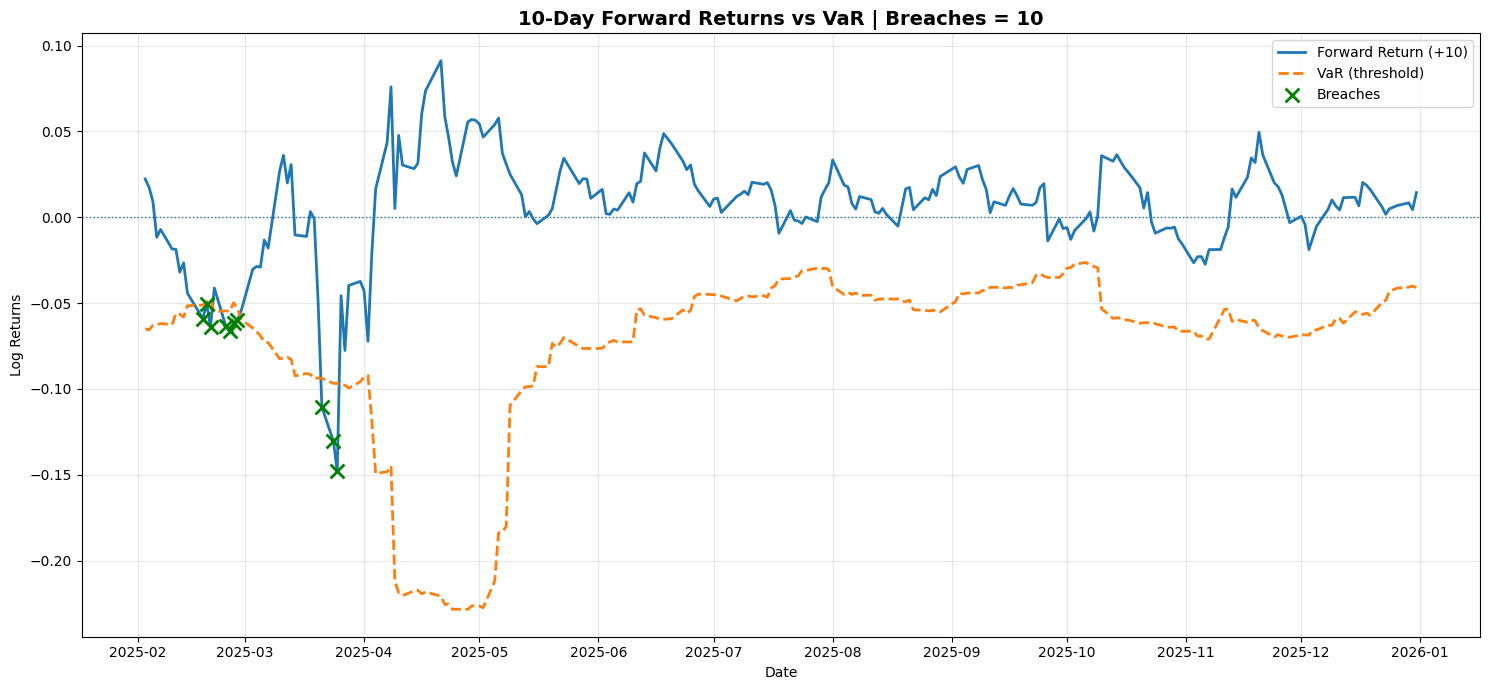

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))


plt.plot(df_new['Date'], df_new['ret_fwd_10'],
         label='Forward Return (+10)', linewidth=2)

plt.plot(df_new['Date'], df_new['VaR_t'],
         linestyle='--', linewidth=2, label='VaR (threshold)')


#plt.fill_between(df_new['Date'], df_new['VaR_t'], 0,
#                 alpha=0.15, label='VaR Loss Region')


breaches = df_new[df_new['Breaches'] == 1]
plt.scatter(breaches['Date'], breaches['ret_fwd_10'],
            marker='x', s=100, linewidths=2,
            color='green', label='Breaches', zorder=5)


plt.axhline(0, linestyle=':', linewidth=1)

# Title with count
n_breaches = df_new['Breaches'].sum()
plt.title(f'10-Day Forward Returns vs VaR | Breaches = {n_breaches}',
          fontsize=14, fontweight='bold')

plt.xlabel('Date')
plt.ylabel('Log Returns')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig('var_backtest.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

Finally, we can compute the traffic lights.

In [30]:
s=sum(df_new['Breaches'])

print(s)

T=len(df_new['Breaches'])

print(T)



10
230


In [31]:
from scipy.stats import binom

p = 0.01

q_green = binom.ppf(0.95, T, p)
q_yellow = binom.ppf(0.9999, T, p)

print(q_green, q_yellow)

5.0 10.0


The traffic lights are as follows:

$$Green:  0 < b \leq 5$$ 


$$ Yellow:  5 < b \leq 10$$


$$ Red:   b > 10$$


Therefore our traffic light is Yellow, given that $b=10$, $ 5<b \leq 10$